In [1]:
# An end-to-end exploratory data analysis pipeline evaluating employee satisfaction,
# workload metrics, and organizational attrition parameters using Numpy, Pandas, Matplotlib and Seaborn.


In [2]:
# Environment & Library Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional theme settings for visualizations
sns.set_theme(style="whitegrid")

In [3]:
# Data Acquisition & Loading

df = pd.read_csv(r'D:\Data Analytics and Scientist Project/people.csv')

In [4]:
# Full Data Inspection

# View the structural dimensions and sample rows of the DataFrame
df

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.11,0.85,7,275,4,0,1,0,support,medium
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [5]:
# 4: Features Data Type Analysis

# Inspect missing parameters and attribute structures
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [6]:
df.describe()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [7]:
df.describe(include='object')

,dept,salary
count,14999,14999
unique,10,3
top,sales,low
freq,4140,7316


In [8]:
# Checking Missing Values

df.isnull().sum() #df.notnull().sum()

satisfactoryLevel        0
lastEvaluation           0
numberOfProjects         0
avgMonthlyHours          0
timeSpent.company        0
workAccident             0
left                     0
promotionInLast5years    0
dept                     0
salary                   0
dtype: int64

In [9]:
# Checking Duplicates

df.duplicated().sum()

np.int64(3008)

In [10]:
# Removing Duplicates

df.drop_duplicates(inplace = True)

In [11]:
# Data Structure

df.shape

(11991, 10)

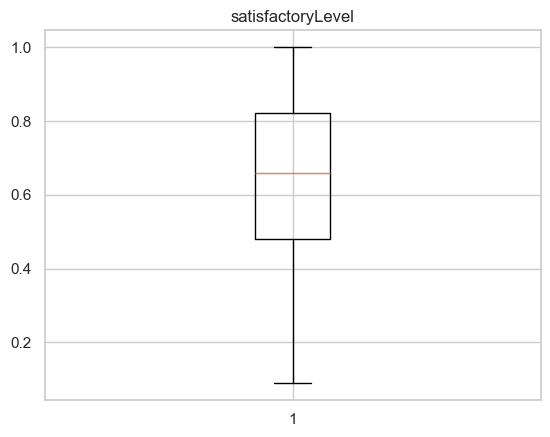

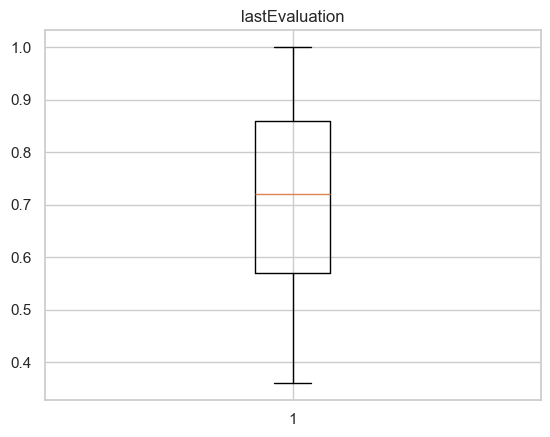

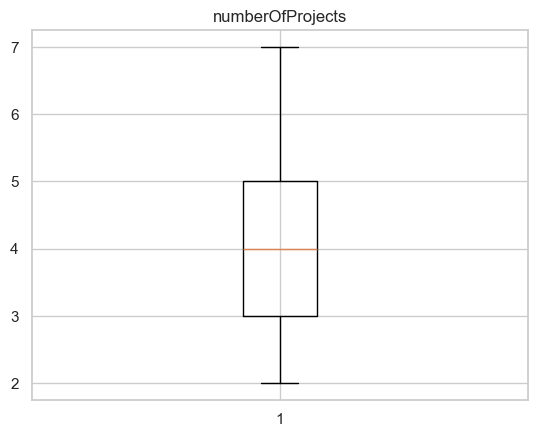

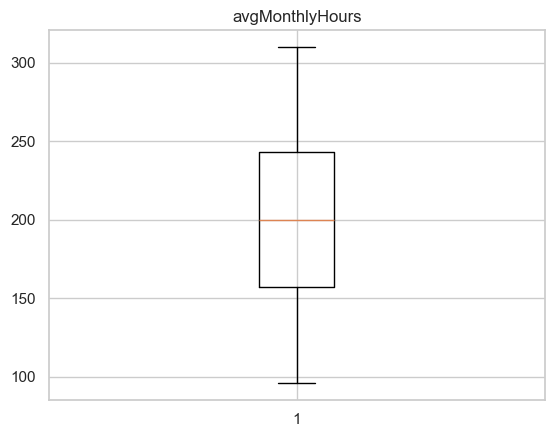

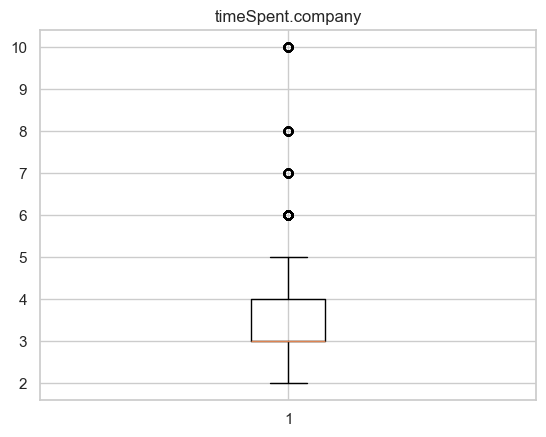

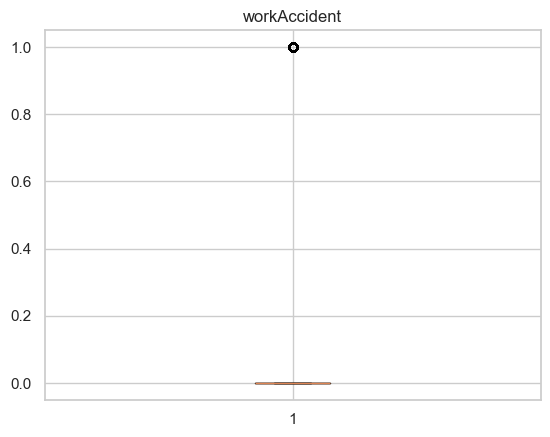

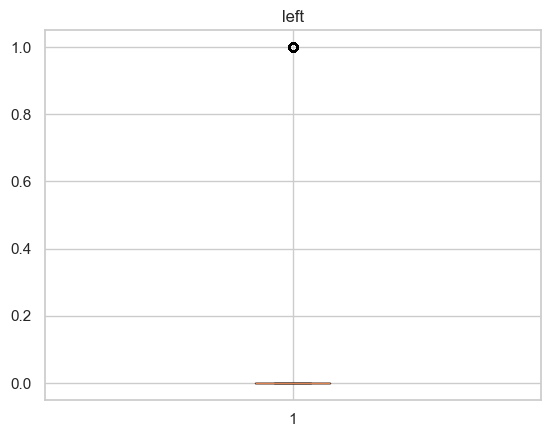

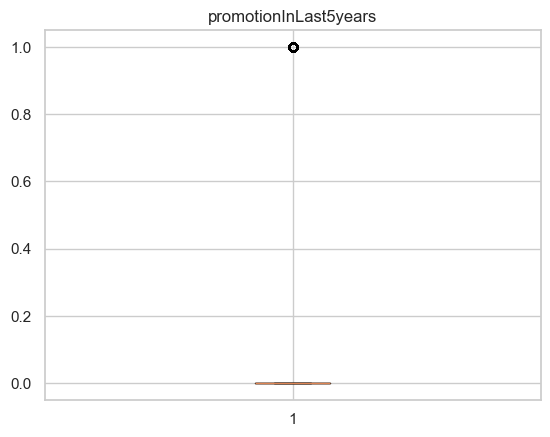

In [12]:
#Outlier Analysis
for col in df.select_dtypes(exclude='object'):
  plt.boxplot(df[col])
  plt.title(col)
  plt.show()

Q1. Using countplot, show how the number of projects is affecting the employee turnover(left)?

<Axes: xlabel='numberOfProjects', ylabel='count'>

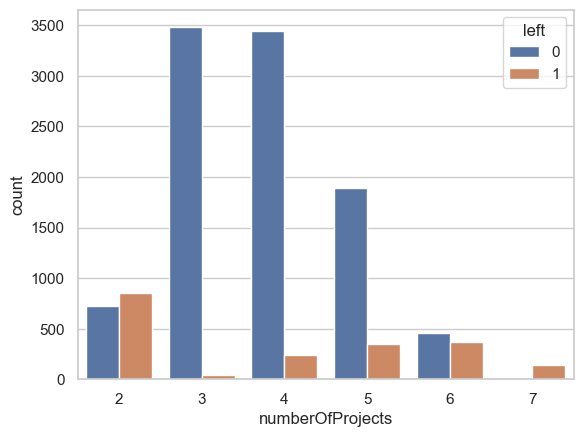

In [13]:
sns.countplot(data = df, x='numberOfProjects',hue='left')

In [14]:
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

Q2. Using countplot, show how the promtion is affecting employee turnover?

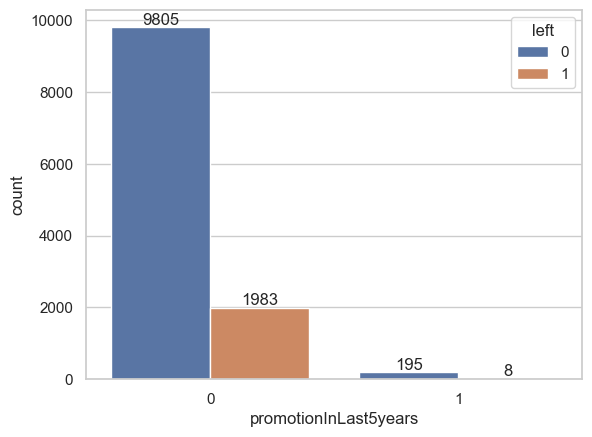

In [15]:
x =sns.countplot(data = df,x='promotionInLast5years',hue = 'left')
for c in x.containers:
 x.bar_label(c)

In [16]:
x.containers

[<BarContainer object of 2 artists>, <BarContainer object of 2 artists>]

Q3. How the monthly working hour is affecting employee turn over?

<Axes: xlabel='avgMonthlyHours', ylabel='Count'>

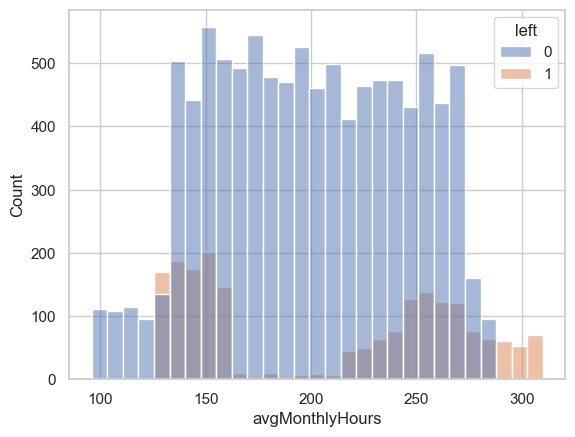

In [17]:
sns.histplot(data=df,x='avgMonthlyHours',hue='left')

Q4. Which department saw the highest employee turnover, and which dept saw the lowest?

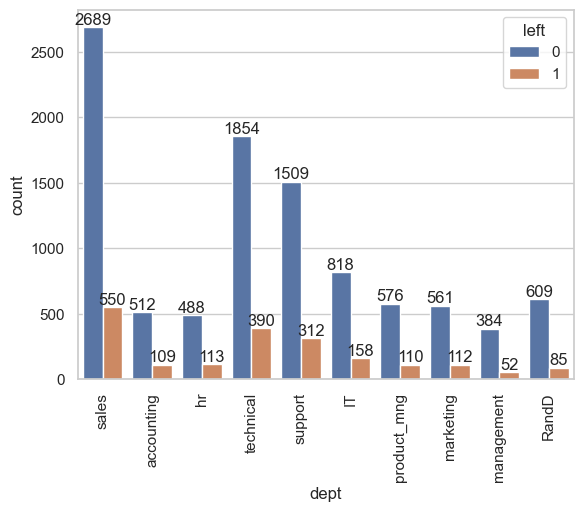

In [18]:
x = sns.countplot(data=df,x='dept',hue='left')
plt.xticks(rotation=90)
for col in x.containers:
  x.bar_label(col)

In [19]:
#pie chart
dfx = df[df['left']==1]

In [20]:
dfx

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14915,0.39,0.57,2,131,3,0,1,0,support,medium
14935,0.83,0.98,4,254,5,0,1,0,technical,low
14941,0.89,0.79,3,149,2,0,1,0,support,medium
14963,0.10,0.93,6,269,4,0,1,0,IT,low


In [21]:
v = dfx['dept'].value_counts()
v

dept
sales          550
technical      390
support        312
IT             158
hr             113
marketing      112
product_mng    110
accounting     109
RandD           85
management      52
Name: count, dtype: int64

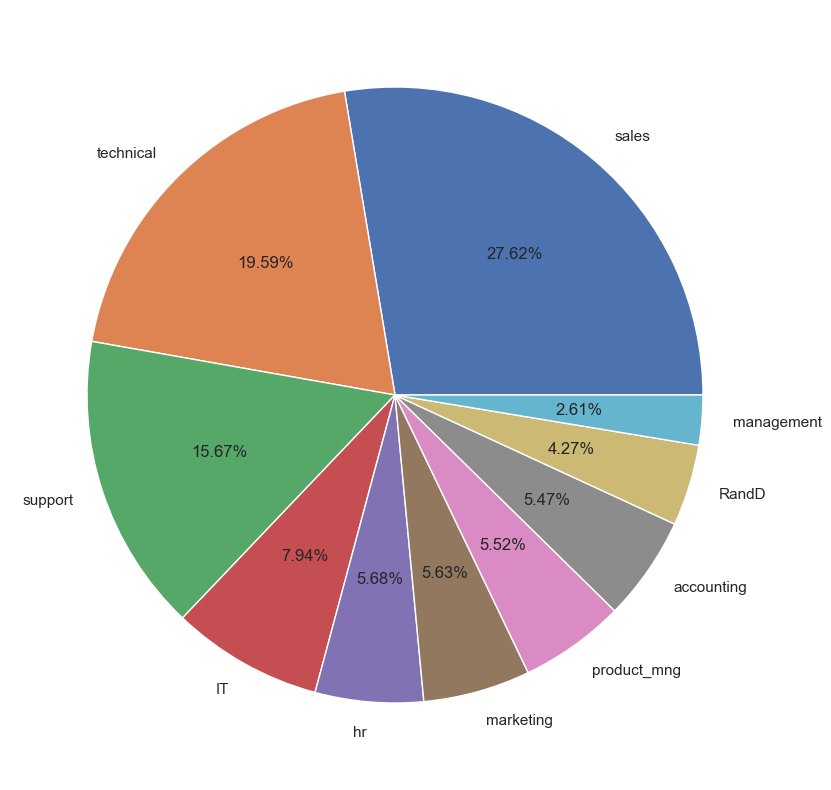

In [22]:
plt.figure(figsize=(10,10))
plt.pie(v,labels= v.index,autopct='%1.2f%%')
plt.show()

Q5. What is the trend between monthly working hours and statisfaction level

<Axes: xlabel='avgMonthlyHours', ylabel='satisfactoryLevel'>

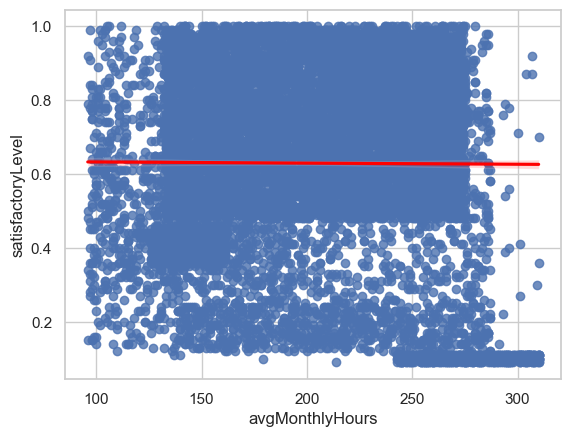

In [23]:
sns.regplot(data=df,x='avgMonthlyHours',y='satisfactoryLevel',line_kws={'color':'red'})

In [24]:
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

Q6. See the trend between lastevaluation and avg monthly hours

<Axes: xlabel='lastEvaluation', ylabel='avgMonthlyHours'>

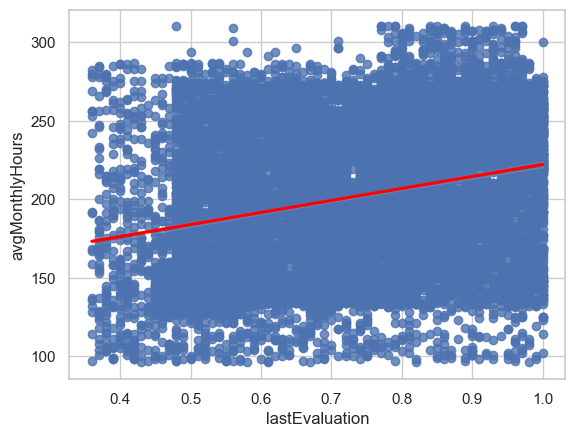

In [25]:
sns.regplot(data = df,x='lastEvaluation',y='avgMonthlyHours',line_kws={'color':'red'})

Q7. How is salary range affecting employee turnover?

<Axes: xlabel='salary', ylabel='count'>

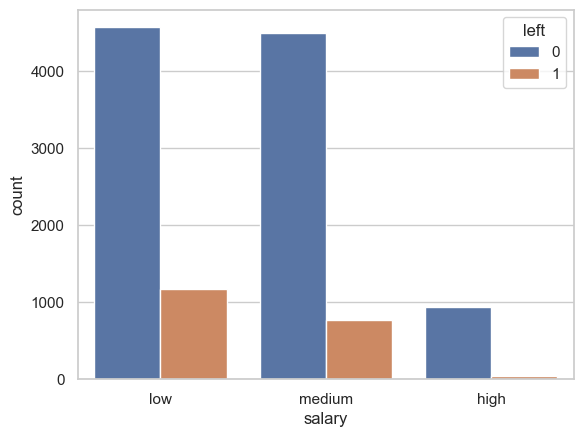

In [26]:
sns.countplot(data=df,x='salary',hue='left')